# 10 — Learned trade/no-trade thresholds

Learn a gate for the W3 survivor (`negative_share`), not a return forecast.
The direction remains the within-session rank of economically oriented
negative share. The target is whether that direction earns a positive h1
abnormal return.

**Chronology.** Fit through 2017; choose the fixed band and probability cutoff
on 2018–2019; disclose 2020–2023 once per frozen arm. Costs are 10 bps/side;
evaluation net-mean intervals use a 20-session circular block bootstrap
(999 replications, seed 20260731).

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_auc_score

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.thresholds import (  # noqa: E402
    FEATURES,
    MIN_ACTIVE_SESSION_SHARE,
    MIN_MEAN_ACTIVE,
    SEED,
    choose_fixed_band,
    choose_probability_cutoff,
    gate_daily_portfolio,
    make_models,
    portfolio_summary,
    prepare_gate_frame,
    split_gate_frame,
)

OUTPUT = REPO_ROOT / "final_experiments" / "outputs" / "10_thresholds"
OUTPUT.mkdir(parents=True, exist_ok=True)
AGG_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "firm_day_aggregators.parquet"
SURPRISE_PATH = REPO_ROOT / "final_experiments" / "outputs" / "04_surprise" / "firm_day_surprise.parquet"

print("fit: <=2017-12-31; validation: 2018-01-01..2019-12-31; evaluation: >=2020-01-01")
print("models: fixed band, logistic, gradient boosted, small MLP, shuffled-label MLP")
print("seed:", SEED)
print("cost: 10 bps/side; inference: 20-session block bootstrap")
print(f"cutoff eligibility: mean active >= {MIN_MEAN_ACTIVE:g}, active-session share >= {MIN_ACTIVE_SESSION_SHARE:.0%}")

fit: <=2017-12-31; validation: 2018-01-01..2019-12-31; evaluation: >=2020-01-01
models: fixed band, logistic, gradient boosted, small MLP, shuffled-label MLP
seed: 20260731
cost: 10 bps/side; inference: 20-session block bootstrap
cutoff eligibility: mean active >= 5, active-session share >= 50%


In [2]:
agg = pd.read_parquet(AGG_PATH)
surprise = pd.read_parquet(SURPRISE_PATH)
frame = prepare_gate_frame(agg, surprise)
train, validation, evaluation = split_gate_frame(frame)
print(f"train={len(train):,}; validation={len(validation):,}; evaluation={len(evaluation):,}")
print("features:", FEATURES)

train=360,489; validation=151,660; evaluation=203,374
features: ('oriented_rank', 'abs_oriented_rank', 'log_article_count', 'dispersion', 'mean_continuous', 'firm_baseline', 'cs_mean', 'ret_lag1')


## Fixed-band baseline first

In [3]:
fixed_band, fixed_sweep = choose_fixed_band(validation)
fixed_sweep.to_csv(OUTPUT / "fixed_band_validation_sweep.csv", index=False)
display(fixed_sweep.round(6))
print("frozen fixed band:", fixed_band)

,band,n_sessions,mean_active,active_session_share,mean_net_exposure,mean_gross,mean_net,mean_turnover,gross_sharpe,net_sharpe,breakeven_bps_per_side,net_mean_ci_low,net_mean_ci_high,bootstrap_block_length,bootstrap_replications,bootstrap_seed
0,0.0,503,301.510934,1.000000,0.000000,0.000053,-0.001275,0.663778,0.426964,-10.278671,0.399295,-0.001447,-0.001102,20,999,20260731
1,0.2,503,264.367793,1.000000,-0.156675,0.000121,-0.001322,0.721550,0.746426,-8.196980,0.837069,-0.001529,-0.001115,20,999,20260731
2,0.4,503,80.546720,1.000000,-0.967738,0.000191,-0.001373,0.781880,0.642184,-4.620320,1.221592,-0.001825,-0.000957,20,999,20260731
3,0.6,503,59.956262,1.000000,-1.000000,0.000112,-0.001522,0.817057,0.355254,-4.835813,0.684865,-0.001926,-0.001151,20,999,20260731
4,0.8,503,31.083499,0.992048,-0.992048,0.000361,-0.001444,0.902740,1.013826,-4.052205,2.001285,-0.001974,-0.000973,20,999,20260731


frozen fixed band: 0.8


## Fit the three declared learned gates

In [4]:
x_train = train[list(FEATURES)]
y_train = train["target_correct_direction"]
x_validation = validation[list(FEATURES)]
x_evaluation = evaluation[list(FEATURES)]

models = make_models(SEED)
frozen = []
cutoff_sweeps = []
probabilities = {}
for name, model in models.items():
    print("fitting", name)
    model.fit(x_train, y_train)
    p_validation = model.predict_proba(x_validation)[:, 1]
    cutoff, sweep = choose_probability_cutoff(validation, p_validation)
    sweep.insert(0, "model", name)
    cutoff_sweeps.append(sweep)
    probabilities[(name, "validation")] = p_validation
    probabilities[(name, "evaluation")] = model.predict_proba(x_evaluation)[:, 1]
    frozen.append(
        {
            "model": name,
            "probability_cutoff": cutoff,
            "validation_auc": roc_auc_score(validation["target_correct_direction"], p_validation),
        }
    )

cutoff_table = pd.concat(cutoff_sweeps, ignore_index=True)
cutoff_table.to_csv(OUTPUT / "learned_gate_validation_sweeps.csv", index=False)
frozen_table = pd.DataFrame(frozen)
frozen_table.to_csv(OUTPUT / "frozen_gate_specs.csv", index=False)
display(frozen_table.round(6))

fitting logistic


fitting gradient_boosted


fitting mlp


,model,probability_cutoff,validation_auc
0,logistic,0.500,0.505994
1,gradient_boosted,0.525,0.505612
2,mlp,0.525,0.503928


## Label-shuffle capacity control

In [5]:
rng = np.random.default_rng(SEED)
shuffled_y = rng.permutation(y_train.to_numpy())
shuffled = make_models(SEED)["mlp"]
shuffled.fit(x_train, shuffled_y)
p_shuffle_validation = shuffled.predict_proba(x_validation)[:, 1]
shuffle_cutoff, shuffle_sweep = choose_probability_cutoff(validation, p_shuffle_validation)
shuffle_sweep.insert(0, "model", "mlp_label_shuffle")
shuffle_sweep.to_csv(OUTPUT / "label_shuffle_validation_sweep.csv", index=False)
p_shuffle_evaluation = shuffled.predict_proba(x_evaluation)[:, 1]
print("shuffled-label MLP cutoff:", shuffle_cutoff)

shuffled-label MLP cutoff: 0.525


## Frozen evaluation comparison

In [6]:
rows = []
fixed_daily = gate_daily_portfolio(
    evaluation,
    evaluation["abs_oriented_rank"] > fixed_band,
)
rows.append({"arm": "fixed_band", "threshold": fixed_band, **portfolio_summary(fixed_daily)})

for spec in frozen:
    name = spec["model"]
    cutoff = float(spec["probability_cutoff"])
    daily = gate_daily_portfolio(evaluation, probabilities[(name, "evaluation")] >= cutoff)
    rows.append(
        {
            "arm": name,
            "threshold": cutoff,
            "evaluation_auc": roc_auc_score(evaluation["target_correct_direction"], probabilities[(name, "evaluation")]),
            **portfolio_summary(daily),
        }
    )

shuffle_daily = gate_daily_portfolio(evaluation, p_shuffle_evaluation >= shuffle_cutoff)
rows.append(
    {
        "arm": "mlp_label_shuffle",
        "threshold": shuffle_cutoff,
        "evaluation_auc": roc_auc_score(evaluation["target_correct_direction"], p_shuffle_evaluation),
        **portfolio_summary(shuffle_daily),
    }
)
evaluation_table = pd.DataFrame(rows)
evaluation_table.to_csv(OUTPUT / "evaluation_gate_comparison.csv", index=False)
display(evaluation_table.round(6))

,arm,threshold,n_sessions,mean_active,active_session_share,mean_net_exposure,mean_gross,mean_net,mean_turnover,gross_sharpe,net_sharpe,breakeven_bps_per_side,net_mean_ci_low,net_mean_ci_high,bootstrap_block_length,bootstrap_replications,bootstrap_seed,evaluation_auc
0,fixed_band,0.800,998,20.888778,0.979960,-0.977956,-0.000130,-0.001941,0.905117,-0.210813,-3.134594,-0.719960,-0.002573,-0.001278,20,999,20260731,NaN
1,logistic,0.500,998,56.202405,1.000000,-0.882153,-0.000309,-0.001962,0.826711,-0.582371,-3.699346,-1.865969,-0.002572,-0.001416,20,999,20260731,0.500513
2,gradient_boosted,0.525,998,6.167335,0.733467,-0.553783,-0.000821,-0.002249,0.714149,-0.708588,-1.937860,-5.745841,-0.003486,-0.001203,20,999,20260731,0.503751
3,mlp,0.525,998,16.251503,0.987976,-0.918473,-0.000119,-0.001981,0.930841,-0.110049,-1.827076,-0.640889,-0.003200,-0.001019,20,999,20260731,0.500662
4,mlp_label_shuffle,0.525,998,16.182365,0.920842,0.111508,-0.001644,-0.003401,0.878397,-0.582418,-1.205234,-9.356613,-0.006447,-0.001272,20,999,20260731,0.492441


## Learned threshold surfaces and granularity feasibility

Mean validation trade probability is tabulated by story-count and dispersion
quintile. This is the interpretable threshold surface; it is not selected on
evaluation. FNSPID has no sector map, so the required sector-conditioned arm
cannot be fit honestly. The plan orders sector before stock, so per-stock
thresholds are also not promoted past feasibility.

,variant,status,reason
0,pooled,COMPLETED,wide FNSPID panel supports pooled development ...
1,per_sector,BLOCKED_MISSING_INPUT,no explicit point-in-time sector map exists fo...
2,per_stock,NOT_RUN_BY_PREDECLARED_ORDER,protocol requires sector-conditioned before st...


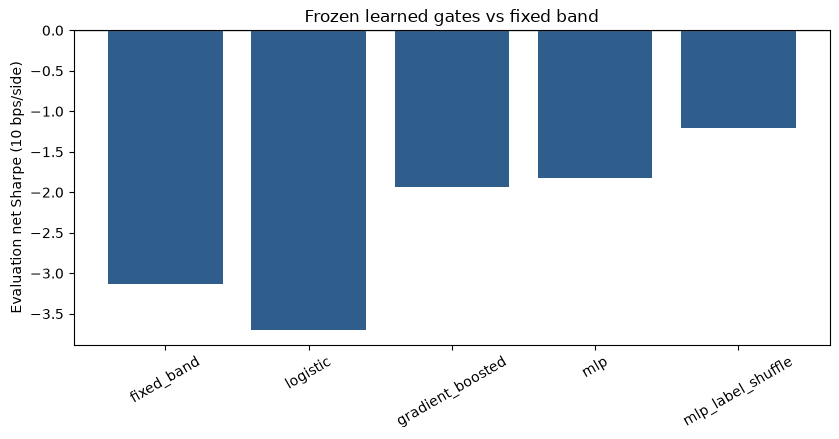

{
  "target": "whether oriented negative-share rank earns positive ar_open_h1",
  "fit": "<=2017-12-31",
  "validation": "2018-01-01..2019-12-31",
  "evaluation": ">=2020-01-01 chronological evaluation block",
  "models": [
    "fixed_band",
    "logistic",
    "gradient_boosted",
    "mlp",
    "mlp_label_shuffle"
  ],
  "features": [
    "oriented_rank",
    "abs_oriented_rank",
    "log_article_count",
    "dispersion",
    "mean_continuous",
    "firm_baseline",
    "cs_mean",
    "ret_lag1"
  ],
  "cost_bps_per_side": 10.0,
  "cutoff_selection_constraints": {
    "minimum_mean_active_names": 5.0,
    "minimum_active_session_share": 0.5
  },
  "bootstrap": {
    "block_length": 20,
    "replications": 999,
    "seed": 20260731
  },
  "sector_variant": "BLOCKED_MISSING_FNSPID_SECTOR_MAP",
  "stock_variant": "NOT_RUN_BECAUSE_SECTOR_FIRST_RULE_IS_BINDING"
}


In [7]:
surface_base = validation[["article_count", "dispersion"]].copy()
surface_base["story_count_bin"] = pd.cut(
    surface_base["article_count"],
    bins=[0, 1, 5, 20, 75, np.inf],
    labels=["1", "2-5", "6-20", "21-75", "76+"],
)
surface_base["dispersion_quintile"] = pd.qcut(surface_base["dispersion"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
surface_rows = []
for spec in frozen:
    name = spec["model"]
    local = surface_base.copy()
    local["trade_probability"] = probabilities[(name, "validation")]
    grouped = (
        local.groupby(["story_count_bin", "dispersion_quintile"], observed=True)
        .agg(mean_trade_probability=("trade_probability", "mean"), n=("trade_probability", "size"))
        .reset_index()
    )
    grouped.insert(0, "model", name)
    grouped["frozen_probability_cutoff"] = spec["probability_cutoff"]
    surface_rows.append(grouped)
surface = pd.concat(surface_rows, ignore_index=True)
surface.to_csv(OUTPUT / "learned_threshold_surfaces.csv", index=False)

feasibility = pd.DataFrame(
    [
        {
            "variant": "pooled",
            "status": "COMPLETED",
            "reason": "wide FNSPID panel supports pooled development fitting",
        },
        {
            "variant": "per_sector",
            "status": "BLOCKED_MISSING_INPUT",
            "reason": "no explicit point-in-time sector map exists for the 570-symbol FNSPID panel",
        },
        {
            "variant": "per_stock",
            "status": "NOT_RUN_BY_PREDECLARED_ORDER",
            "reason": "protocol requires sector-conditioned before stock-specific thresholds",
        },
    ]
)
feasibility.to_csv(OUTPUT / "threshold_granularity_feasibility.csv", index=False)
display(feasibility)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
plot = evaluation_table.set_index("arm")
ax.bar(plot.index, plot["net_sharpe"], color="#2f5d8c")
ax.axhline(0, color="#666", lw=1)
ax.set_ylabel("Evaluation net Sharpe (10 bps/side)")
ax.set_title("Frozen learned gates vs fixed band")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(OUTPUT / "evaluation_gate_comparison.png", dpi=150)
plt.show()

manifest = {
    "target": "whether oriented negative-share rank earns positive ar_open_h1",
    "fit": "<=2017-12-31",
    "validation": "2018-01-01..2019-12-31",
    "evaluation": ">=2020-01-01 chronological evaluation block",
    "models": ["fixed_band", "logistic", "gradient_boosted", "mlp", "mlp_label_shuffle"],
    "features": list(FEATURES),
    "cost_bps_per_side": 10.0,
    "cutoff_selection_constraints": {
        "minimum_mean_active_names": MIN_MEAN_ACTIVE,
        "minimum_active_session_share": MIN_ACTIVE_SESSION_SHARE,
    },
    "bootstrap": {"block_length": 20, "replications": 999, "seed": SEED},
    "sector_variant": "BLOCKED_MISSING_FNSPID_SECTOR_MAP",
    "stock_variant": "NOT_RUN_BECAUSE_SECTOR_FIRST_RULE_IS_BINDING",
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))